# RealLift: End-to-End Geographic Experiment Tutorial

Welcome to the **RealLift Quick Start Guide**. In this tutorial, we will walk through the complete lifecycle of a geographic incremental test, from generating historical data to selecting the optimal test clusters and measuring the final business impact.

RealLift uses **Synthetic Control** and **Matched Difference-in-Differences (DiD)** methodologies to provide a robust, counterfactual-based framework for marketing measurement.

## 1. Installation

First, let's install the library from PyPI.

In [ ]:
%pip install reallift

## 2. Step 1: Historical Data Simulation (Pre-test)

Before running an experiment, we need historical baseline data to understand natural correlations between geographies. 

We will use `generate_geo_data` to create a dataset for 27 geographies with:
- **Seasonality**: Simulating weekly patterns (period=7).
- **Trend**: General market growth.
- **Noise**: Random variance to test robustness.
- **Pre-only**: We will generate only the baseline period (60 days).

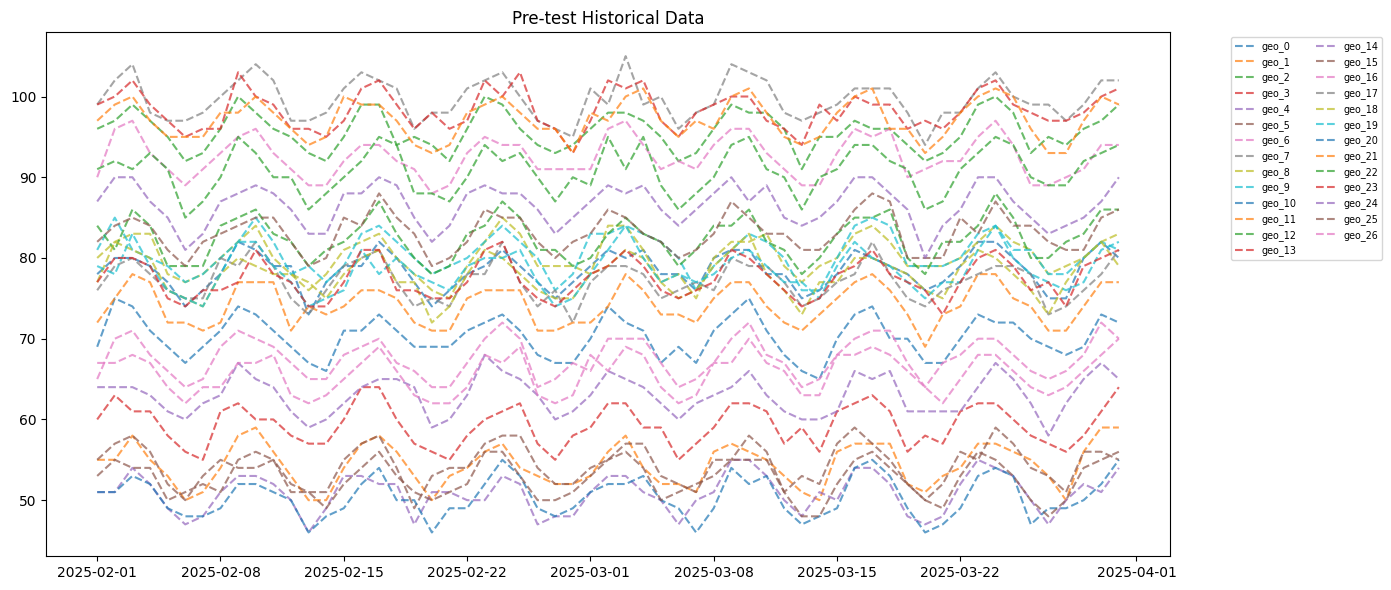

In [10]:
from reallift import generate_geo_data

file_pre_test = 'demo_geodata_pre_test.csv'
start_date = "2025-02-01"
end_date = "2025-03-31"

geo_data = generate_geo_data(
    start_date = start_date,
    end_date = end_date,
    n_geos=27,
    pre_only=True,
    trend_slope=0.01,
    seasonality_amplitude=3,
    seasonality_period=7,
    noise_std=[1, 1.2],
    base_value=[50, 100],
    random_seed=42,
    save_csv=True,
    pre_file_name=file_pre_test,
    as_integer=True,
)

## 3. Step 2: Design of Experiments (DoE)

The **Design of Experiments (DoE)** phase is critical. It evaluates which combinations of treatment and control geos provide the highest statistical power and lowest prediction error.

The output will show:
- **Cluster Recommendations**: Which geos should be treated.
- **MDE (Minimum Detectable Effect)**: What is the smallest lift we can confidently detect for a given duration.

In [11]:
from reallift import design_of_experiments

doe = design_of_experiments(
    filepath=file_pre_test,
    date_col="date",
    start_date=start_date,
    end_date=end_date,
    pct_treatment=None,
    fixed_treatment=None,
    experiment_days=[21, 28, 30, 35, 60],
)


======================= DESIGN OF EXPERIMENTS ========================

Total geos available: 27
Scenarios to evaluate: 3
Search mode: ranking
Pre-treatment period: 2025-02-01 → 2025-03-31
Experiment duration: [21, 28, 30, 35, 60]

Screening all geos individually...


Screening geos: 100%|██████████| 27/27 [00:01<00:00, 19.00it/s]


Global ranking (top 8): ['geo_21', 'geo_2', 'geo_16', 'geo_26', 'geo_0', 'geo_8', 'geo_24', 'geo_23']

----------------------------------------------------------------------
SCENARIO 1 — 10% Treatment (3 geos)
----------------------------------------------------------------------

  [Greedy Sequential Search] Screening through ranking queue...
    - Candidate: geo_21     Approved (OOF R² = 0.7886, Gap = 0.0368, Iters: 6)      
    - Candidate: geo_2      Approved (OOF R² = 0.7111, Gap = 0.1169, Iters: 9)      
    - Candidate: geo_16     Approved (OOF R² = 0.7073, Gap = 0.1538, Iters: 9)      

  Cluster | Treatment  | Controls | MDE @21d  | MDE @28d  | MDE @30d  | MDE @35d  | MDE @60d 
  --------------------------------------------------------------------------------------------
  0       | geo_21     | 6        | 0.79%     | 0.68%     | 0.66%     | 0.61%     | 0.46%    
  1       | geo_2      | 3        | 0.92%     | 0.79%     | 0.77%     | 0.71%     | 0.54%    
  2       | geo_16   

## 4. Step 3: Injecting Simulated Marketing Intervention

To validate that our model can actually "find" an effect, we will take the optimal treatment geographies from the DoE (`treatment_pool`) and manually inject an artificial lift of 5% to 10% for 21 days.

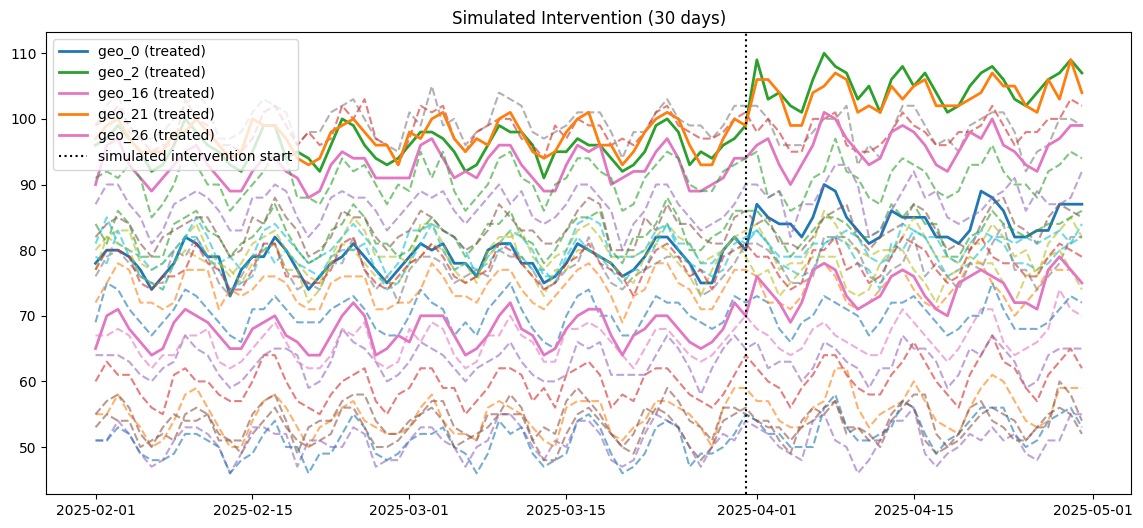

In [12]:
from reallift import generate_simulated_intervention

file_post_test = 'demo_geodata_post_test.csv'

geo_data_intervention = generate_simulated_intervention(
    filepath=file_pre_test,
    days=30,
    treatment_geos=doe['scenarios'][1]['treatment_pool'], # Using the best scenario from DoE
    lift=[0.05, 0.10],
    random_seed=42,
    save_csv=True,
    as_integer=True,
    file_name=file_post_test
)

## 5. Step 4: Measuring the Incremental Impact

Now we run the inference pipeline. This step inherits the experiment design from the DoE (`scenario=1`) and calculates:
- **Total Incremental Lift**: The count/financial gain caused by the campaign.
- **Bootstrap Significance**: Confirming the lift is statistically different from zero.
- **Placebo MSPE Ratio**: A rigorous test to ensure the effect is unique to our treated areas.

In [13]:
from reallift import run_geo_experiment

results = run_geo_experiment(
    filepath=file_post_test,
    date_col="date",
    treatment_start_date="2025-04-01",
    treatment_end_date="2025-04-30",
    doe=doe, 
    scenario=1, # Matching the scenario choice in Step 3
    plot=False
)


>>> Using experiment design from DoE Scenario 1

--------------------------------------------------
-------------- ANALYZING CLUSTER 0 ---------------
--------------------------------------------------
Treatment: ['geo_21']
Final Exclusive Controls: ['geo_5', 'geo_7', 'geo_17', 'geo_18', 'geo_24']


=== GEO SYNTHETIC CONTROL (Cluster 0) ===

Weights:
geo_5: 0.0711
geo_7: 0.2768
geo_17: 0.2596
geo_18: 0.2402
geo_24: 0.1524

Treatment period:
Start: 2025-04-01
End: 2025-04-30
Duration: 30 days

Mean lift (abs): 6.94
Mean lift (%): 7.18 %
Total lift: 208.13

=== SIGNIFICANCE (Cluster 0) ===

T-Test:
t-stat: 21.793
p-value: 0.0000

=== BOOTSTRAP TESTS SUMMARY (Cluster 0) ===
Total lift (abs): 208.13
95% CI (abs): [190.06, 225.98]
Total lift (%): 7.16%
95% CI (%): [6.52%, 7.80%]
p-value (bootstrap): 0.0000
[Yes] Lift statistically significant (CI does not cross 0)

=== GEO PLACEBO TESTS (Cluster 0) ===
Number of placebo tests: 5
Observed MSPE Ratio: 51.1925
P-value (placebo): 0.0000
[Yes] 